In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

df = pd.read_csv('StudentsPerformance.csv')


# First Look

print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

/Users/ruhil/student-score-analysis
(1000, 8)
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Col

In [8]:
df.columns.tolist()
df.head(3)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93


In [9]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [10]:
df.groupby('gender')[['math score','reading score','writing score']].mean().round(2)

,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


In [11]:
df.groupby('test preparation course')[['math score','reading score','writing score']].mean().round(2)

,math score,reading score,writing score
test preparation course,,,
completed,69.70,73.89,74.42
none,64.08,66.53,64.50


In [19]:
print(df.groupby('parental level of education')['math score'].mean().round(2).sort_values(ascending=False).rename('avg_maths-score'))

parental level of education
master's degree       69.75
bachelor's degree     69.39
associate's degree    67.88
some college          67.13
some high school      63.50
high school           62.14
Name: avg_maths-score, dtype: float64


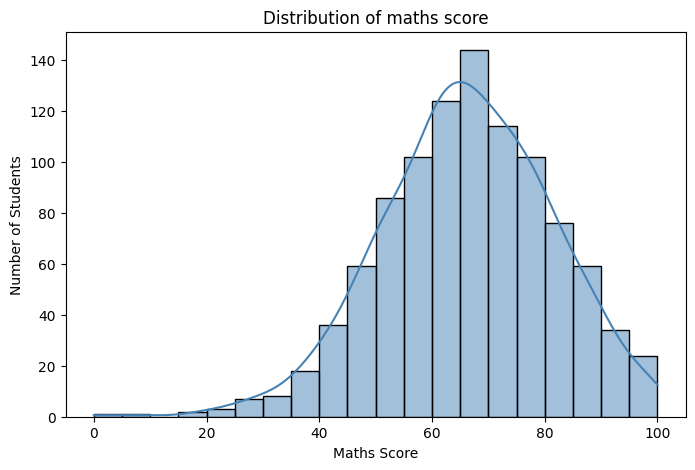

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['math score'],bins=20, kde=True, color='steelblue')
plt.title('Distribution of maths score')
plt.xlabel('Maths Score')
plt.ylabel('Number of Students')
plt.savefig('maths_score_dist.png')
plt.show()


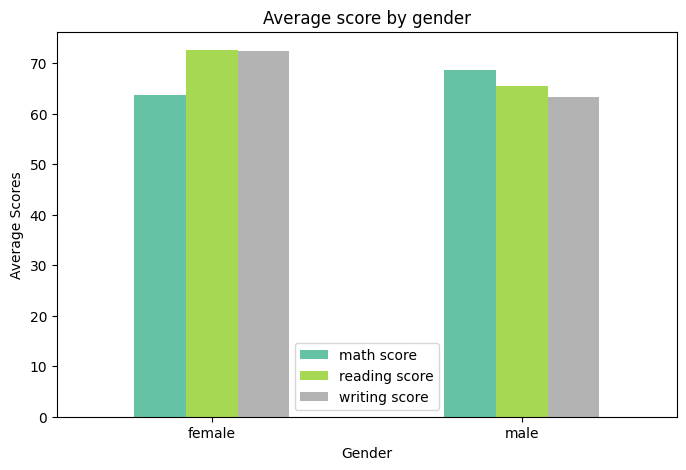

In [ ]:
gender_avg = df.groupby('gender')[['math score','reading score','writing score']].mean().round(2)
gender_avg.plot(kind= 'bar', figsize=(8,5), colormap='Set2')
plt.title('Average score by gender')
plt.xlabel('Gender')
plt.ylabel('Average Scores')
plt.xticks(rotation=0)
plt.savefig('Average_scores_by_gender.png')
plt.show()

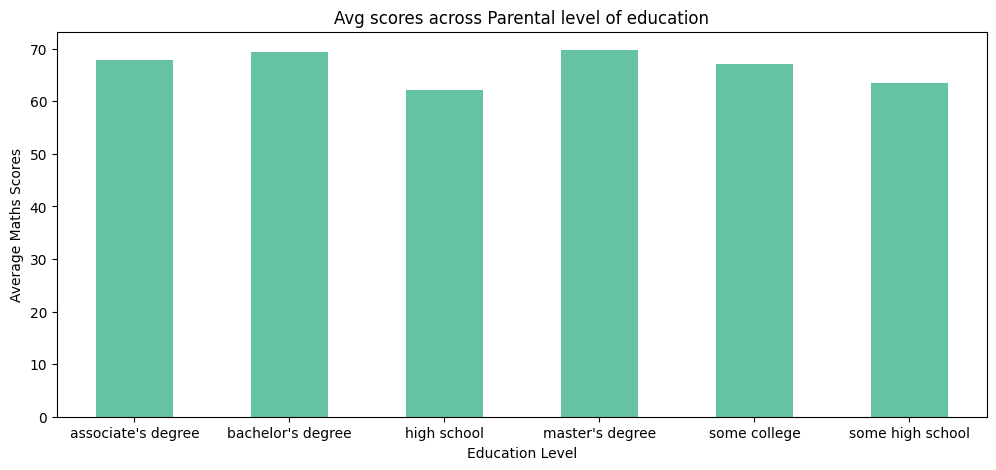

In [26]:
gender_avg = df.groupby('parental level of education')['math score'].mean().round(2)
gender_avg.plot(kind= 'bar', figsize=(12,5), colormap='Set2')
plt.title('Avg scores across Parental level of education')
plt.xlabel('Education Level')
plt.ylabel('Average Maths Scores')
plt.xticks(rotation=0)
plt.savefig('Average_scores_by_level of education.png')
plt.show()

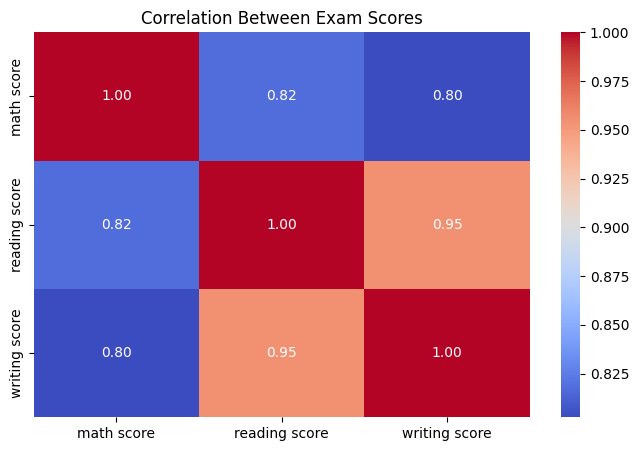

In [31]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['math score','reading score','writing score']].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Between Exam Scores')
plt.savefig('correlation-heatmap.png')
plt.show()

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score
import numpy as np


# Features and target 
X = df[['reading score','writing score']]
y = df['math score']

# Split data
X_train , X_test ,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#Train Model
model = LinearRegression()
model.fit(X_train,y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print(f"R2 Score:{r2_score(y_test , y_pred):.4f}")
print(f"RMSE:{np.sqrt(mean_squared_error(y_test,y_pred)):.4f}")

R2 Score:0.6826
RMSE:8.7888


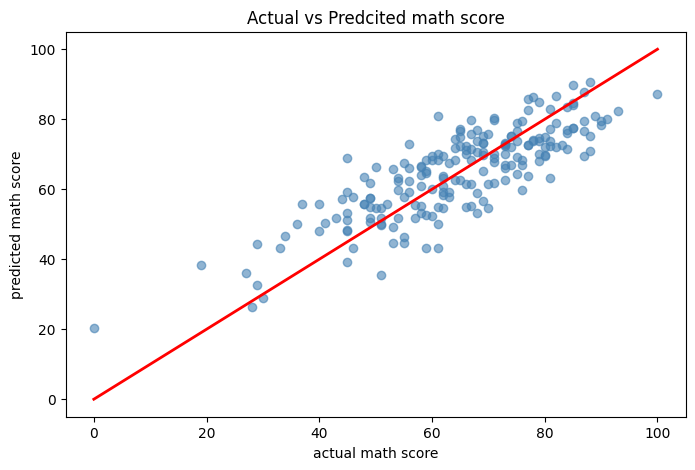

In [35]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='steelblue',alpha=0.6)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color='red',linewidth =2)
plt.xlabel('actual math score')
plt.ylabel('predicted math score')
plt.title("Actual vs Predcited math score")
plt.savefig('actual_vs_predicted_math_score.png')
plt.show()